# Spike sorting pipeline with kilosort4 demonstration notebook

This notebook is to demonstrate how spike sorting pipeline works step-by-step.

It is only used for demonstration (because it's slow and stops on each step). If you run sorting for real experiments, it is more recommended to use run_sorting_pipeline.py with your session config.

```bash
python run_sorting_pipeline.py   --config configs/session_demo_1probe.yaml
# ... curate in Phy ...
python run_exporting_pipeline.py --config configs/session_demo_1probe.yaml
```

This notebook shows the by-step logic behind the run_sorting_pipeline.py. What is run below (except for the gui) is the same as what is doing inside run_sorting_pipeline.py.

### Optional step1: Check the recording using kilosort GUI

It is recommended by the official manuel that it's better to check the data first from kilosort gui. If plan to do so, just use terminal or just run the blow cell to turn on GUI. The instruction for the gui is here : https://kilosort.readthedocs.io/en/latest/gui_guide.html

The kilosort manuel said using GUI could be helpful in finding out bad channels, or deciding whether to use whitening, etc

In [5]:
!python -m kilosort

You can run the sorting process through GUI directly actually. But run through script has more flexibility for batch sorting.

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import spikesorting as ss

print(REPO)
print("verbs:", ", ".join(n for n in ss.__all__ if n[0].islower()))

c:\SpikeSorting\SpikeSortingKilosort
verbs: skip_reason, load_session_config, setup_probe, sort_with_kilosort, extract_sync, extract_lfp, time_remapping, validate_remapping, export_results, export_waveforms, stamp_lfp_timebase, load_machine, stream_label


## 1. Load the session configuration

In the first step before real soring begins, it set up two configurations:

 **the machine**: where this script run. For 90% of time, I bet this will be run on the windows rig/sorting machine or HPC. You don't need to modify the default settings there usually. 

 **the session**: what parameters we will use in this session.
 I have established 4 templates which should cover most of cases in the lab. 
 
 For this demo, choose session_demo_1probe.yaml. 

 Inside the session config yaml, it defines the path for the recording data (.bin) and several parameters 
 related to the sorting. 

 For your own experiment, feel free to copy one config yaml file template and make modifications based on your experiments.




In [10]:
config = ss.load_session_config(REPO / "configs" / "session_demo_1probe.yaml", "windows_rig")
try:
    config.paths.mkdirs()
except OSError as error:
    print(f'could not create output dirs: {error}\n')

print(f"session:   {config.session}")
print(f"machine:   {config.machine.name}  (device={config.machine.device})")

# cache is where the pipeline actually run on. It usually points to a high speed SSD on the local PC. 
# When sorting completes, the output will be moved to the data folder for convenience.
print(f"cache:     {config.cache_dir}")
# CatGT is a command line tool for edge extraction of the 1Hz synchronize pulse.If CatGT is not installed, I have added a python-based script for extraction.
print(f"CatGT:     {config.machine.catgt_dir or 'not installed -> NumPy fallback'}")
# Tprime is a command line tool for alignment and time remap.
# The above two tools will be in need in the exproting step after sorting.


session:   session_demo_1probe
machine:   windows_rig  (device=cuda)
cache:     D:\kilosort_cache
CatGT:     C:\SpikeGLX\CommandLineTools\CatGTWinApp\CatGT-win


## 2. Set up the probe

Kilosort relies heavily on the configuration of the probe. It needs those information to infer spikes from nearby channels. A wrong probe file will lead to a sorting failure. 

Luckily, Neuropixel data usually saves with a meta file containing it's recording probe information.

So it can be automatically retrived through the meta file. For Utah array recording, the probe file can be retrived through cmp file. 

But if a meta file or a cmp file is not founded, you have to define the dir for a probe file manuelly. Otherwise it will report error.

| | Neuropixels | Blackrock |
|---|---|---|
| 1 | the run's `.meta` (`~snsGeomMap`) | `blackrock.probe_file` |
| 2 | `neuropixels.probe_file` | **raises** -- no honest default |
| 3 | **raises** -- no honest default | |

One key per system, whatever the map's format: `probe_file` is read by its
extension -- `.cmp`, `.json` or `.mat`.

This demo session does not come with it's meta file. So it will load through the probe_file downloaded throug h the setup_demo_data notebook.


In [17]:
# The probe file is already setup throug the session_demo_1probe.yaml file.
probe_file = config.neuropixels.probe_file
print(f'The probe config: {probe_file}')
SYSTEM = "neuropixels" #it can be neuropxiels or blackrock. Once define it, the following setup probe will automatically setup probe through probe_file
probe = ss.setup_probe(config, SYSTEM)
print(f"{probe['n_chan']} channels, placeholder geometry: {probe.get('_placeholder', False)}")
print(f"  x positions : {sorted(set(np.asarray(probe['xc']).tolist()))}")
print(f"  y range     : {min(probe['yc'])} -> {max(probe['yc'])} um")
print(f"  shanks      : {len(set(np.asarray(probe['kcoords']).tolist()))}")
#If meta file is not recognized and there is no file in probe_file defined, it will report error.

The probe config: C:\SpikeSorting\SpikeSortingKilosort\configs\probes\np1_default.json
384 channels, placeholder geometry: False
  x positions : [11.0, 27.0, 43.0, 59.0]
  y range     : 20.0 -> 3840.0 um
  shanks      : 1


## 3. Sort with Kilosort4

`sort_with_kilosort(config, system)` is the whole of pipeline 1. It resolves the map,
names the binary Kilosort reads, and calls Kilosort4's own `run_kilosort` on it.

**What each system hands it.** SpikeGLX already writes a flat int16 binary, which is
exactly Kilosort's format, so nothing is converted. A Blackrock `.ns6` is not flat, so
SpikeInterface's `read_blackrock` reads it and Kilosort's `io.spikeinterface_to_binary`
writes it out once.

**The preprocessing kilosort do before actual sorting.** Kilosort subtracts
the median across channels when `do_CAR` is set (the default), highpasses at
`highpass_cutoff` (300 Hz), then whitens and drift-corrects. Which of those to turn on
is named under `kilosort:` in the session config; `config.kilosort_for(system)` is that block,
split here into Kilosort's `settings` dict and `run_kilosort`'s own arguments by asking
the installed Kilosort which is which. `bad_channels` removes a list you supply.

Sorting runs in the machine's SSD cache and the results are copied out, so nothing large
is written over the network share. Returns `None` without sorting when
`kilosort_on_<system>` is false.

This is the slow cell and the only one needing a GPU. On a real session run it from
`run_sorting_pipeline.py` so it survives a closed laptop, or send it to a cluster:

```bash
python run_sorting_pipeline.py --config configs/<s>.yaml --machine windows_rig
```

### Below I first run a dry-run, which is not sorting anything, but to check whether the file is ready: Whether the data file can be detected, whether probe file can be deteced, etc.

In [18]:
# dry_run resolves everything and sorts nothing, so it works on a laptop.
print("will it sort?", ss.skip_reason(config, ss.sort_with_kilosort, SYSTEM) or "yes")
for key, value in (ss.sort_with_kilosort(config, SYSTEM, dry_run=True) or {}).items():
    print(f"  {key:32} {value}")

will it sort? yes
  probe                            {'n_chan': 384, 'x_range_um': [11.0, 59.0], 'y_range_um': [20.0, 3840.0], 'n_groups': 1, 'placeholder_geometry': False}
  binary                           Z:\Monkey neuropixel_demo\demo\ZFM-02370_mini.imec0.ap.short.bin (385 channels at 30000 Hz)
  results_dir                      Z:\Monkey neuropixel_demo\demo\kilosort4
  settings                         {'n_chan_bin': 385, 'fs': 30000.0}
  run_kilosort arguments           {}


### Now it's the real run on kilosort4, it may takes a while....

In [19]:
try:
    result = ss.sort_with_kilosort(config, SYSTEM)
    print(result.summary() if result else "nothing to sort")
except Exception as error:
    print(f"cannot sort on this machine: {type(error).__name__}: {error}")

kilosort.run_kilosort: Kilosort version 4.1.7
kilosort.run_kilosort: Python version 3.11.15
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: System information:
kilosort.run_kilosort: Windows-10-10.0.26200-SP0 AMD64
kilosort.run_kilosort: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel
kilosort.run_kilosort: Using CUDA device: NVIDIA GeForce RTX 5060 7.96GB
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: Sorting [WindowsPath('Z:/Monkey neuropixel_demo/demo/ZFM-02370_mini.imec0.ap.short.bin')]
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage before sorting
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     4.10 %
kilosort.run_kilosort: Mem used:     47.60 %     |      15.02 GB
kilosort.run_kilosort: Mem avail:    16.54 / 31.56 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort

280 units, 431328 spikes at 30000 Hz -> Z:\Monkey neuropixel_demo\demo\kilosort4


### If sorting Utah array on Blackrock...

Nothing changes but the argument. The map comes from the array's `.cmp` rather than the
run's `.meta`, and the `.ns6` is transformed into a binary on the way in -- but that is
inside the verb, and the call is the same.

`skip_reason` is what the runner scripts print for a `[--]` line: which systems recorded
is derived from the paths the session declares, and whether to sort them is the one
thing paths cannot say.

In [ ]:
for system in ss.SYSTEMS:
    print(f"{system:12} declared={config.has_data(system)} "
          f"sorts={getattr(config, f'sorts_{system}')} "
          f"-> {config.paths.dir_for(system)}")
    for verb in (ss.setup_probe, ss.sort_with_kilosort):
        why = ss.skip_reason(config, verb, system)
        print(f"    {verb.__name__:24} {why or 'will run'}")

## 4. Curate in Phy

Now for this step, go to the kilosort4 folder, right click, open a terminal, and do manuel curation using phy.
```bash
conda activate phy
```

```bash
phy template-gui params.py
```

Phy writes `cluster_group.tsv`, whose labels override Kilosort's own
`cluster_KSLabel.tsv`. Everything downstream reads the human labels when they exist.

## 5. Extract the sync pulses (pileline2  run_exporting_pipeline.py)

After manuel curation, the next steps are all around time mapping. There are two steps:

**1.Extract synchromize pulses to establish a time map between blackrock and neuropixel**

There are two synchronize pulses: 1Hz sent from Onebox to BR, saved by both system; 14s-pulses pattern sent from BR to OneBox, saved by both system. The blackrock 14s pulse can be used to identify the absolute time difference netween BR and OneBox. Then the 1Hz pulse can be used for finer alignment.

For this demo, there is no BR file to synchromize, so it will directly go to step2

**2. Map the timestamp back to the sorted unit.**

The finally export spike time data will be in the mapped timestamp



In [23]:
print(config.machine.name, config.machine.catgt_dir)
print(config.neuropixels.bin_file)
#print("\n".join(report.notes))

windows_rig C:\SpikeGLX\CommandLineTools\CatGTWinApp\CatGT-win
Z:\Monkey neuropixel_demo\demo\ZFM-02370_mini.imec0.ap.short.bin


In [29]:
#  1. extract two synchronize pulses
try:
    report = ss.extract_sync(config, SYSTEM)
    print(report.summary() if report else "nothing to extract")
except OSError as error:
    report = None
    print(f"recording not reachable: {error}")

npx_1hz: 44 edges via numpy spanning 43.0 s <- ZFM-02370_mini.imec0.ap.short.bin SY bit 6
       CatGT skipped: neuropixels.bin_file is not named like SpikeGLX output (<run>_g<n>_t<n>.imec<n>.ap.bin), so there is no run for it to read.
       Neuropixels 14 s burst extraction skipped: no OneBox (obx) stream found.


Look at what came out. For a 1 Hz square wave the intervals should sit on 1.000 s with
jitter of about one sample (33 us at 30 kHz).

npx_1hz: 44 edges from numpy, span 43.0 s
    interval mean 1.000002 s, jitter 8.5 us


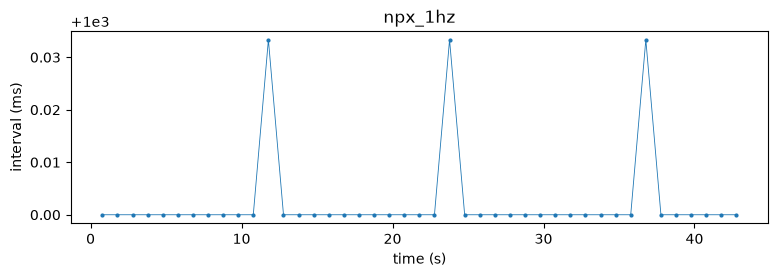

In [30]:
for name, edges in sorted((report.edge_sets if report else {}).items()):
    times = edges.times_s
    print(f"{name}: {edges.n} edges from {edges.source}, span {edges.span_s:.1f} s")
    if times.size > 2:
        intervals = np.diff(times)
        print(
            f"    interval mean {intervals.mean():.6f} s,"
            f" jitter {intervals.std() * 1e6:.1f} us"
        )
        figure, ax = plt.subplots(figsize=(9, 2.5), dpi=100)
        ax.plot(times[:-1], intervals * 1e3, ".-", markersize=4, linewidth=0.6)
        ax.set_xlabel("time (s)")
        ax.set_ylabel("interval (ms)")
        ax.set_title(name)
        plt.show()

A run with no pulses reports zero edges rather than failing — that is the correct
result for a recording made without SMA1 connected. Check `result.notes`; it also
records the CatGT command that *would* have run, so a rig run can be reproduced by hand.

## 6. Map onto the Blackrock timebase

`time_remapping(config, system)` maps `system` onto Blackrock. Blackrock is the
reference, so it is not an argument -- and asking to remap Blackrock itself returns
`None`, since there is nothing to map the reference onto.

1. coarse offset from the 14 s coded bursts (which resolve *which* 1 Hz cycle);
2. both 1 Hz trains trimmed to their overlapping window;
3. fine fit via TPrime, or least squares on the same matched edges;
4. `validate_remapping` checks it against the burst onsets, held out of the fit.

Skipped for the demo: there is no second system.

In [31]:
print(ss.time_remapping(config, "neuropixels") or "no remapping for this session")
print(ss.validate_remapping(config) or "no validation for this session")

no remapping for this session
no validation for this session


The pure-compute pieces are worth knowing individually — they take arrays and return
arrays, so you can drive them on your own edge lists without any config at all.

Below, two synthetic systems: SpikeGLX starts 137.5 s later on its own clock and runs
30 ppm fast. Note the order — the **coded burst** supplies the coarse offset, and only
then is the 1 Hz train used. Doing it the other way round does not work, for a reason
worth seeing (two cells down).

In [32]:
from spikesorting._sync import align, burst

OFFSET, DRIFT = 137.5, 30e-6
rng = np.random.default_rng(0)


def coded_bursts(n, interval=14.0, pulses=8, gap=0.02):
    """Dense bursts every `interval` s, each with its own intra-burst pattern."""
    times = []
    for i in range(n):
        onset = i * interval
        times.append(onset)
        times.extend(onset + np.cumsum(gap * (1 + rng.uniform(0, 1, pulses - 1))))
    return np.sort(np.asarray(times))


to_spikeglx = lambda t: (t - OFFSET) / (1 + DRIFT)

blackrock_1hz = np.arange(0.0, 1200.0, 1.0)
blackrock_burst = coded_bursts(int(1200 // 14))
# SpikeGLX started late, so it missed the first 200 s that Blackrock caught.
spikeglx_1hz = to_spikeglx(blackrock_1hz[blackrock_1hz >= 200.0])
spikeglx_burst = to_spikeglx(blackrock_burst[blackrock_burst >= 200.0])

# 1. Coarse offset from the coded burst.
match = burst.match_bursts(blackrock_burst, spikeglx_burst, min_gap_s=7.0, tolerance_s=0.05)
print(f"coarse offset : {match.offset_s:.6f} s  (planted {OFFSET})")
print(f"                {match.n_matched} bursts matched, "
      f"pulse score {match.pulse_score} vs runner-up {match.runner_up_score}")

# 2. Trim both 1 Hz trains to the overlapping window, then 3. fit the fine map.
br_trim, npx_trim = align.trim_pair_to_overlap(
    blackrock_1hz, spikeglx_1hz, match.offset_s, margin_s=0.25
)
ref_idx, other_idx = burst.match_times(br_trim, npx_trim, match.offset_s, tolerance_s=0.25)
mapping = align.fit_linear_map(npx_trim[other_idx], br_trim[ref_idx])

print(f"matched edges : {mapping.n_points}")
print(f"slope         : {mapping.slope:.9f}  ({mapping.drift_ppm:+.2f} ppm)")
print(f"intercept     : {mapping.intercept:.6f} s  (planted {OFFSET})")
print(f"fit residual  : {np.abs(mapping.residuals_s).max() * 1e6:.3f} us max")

coarse offset : 137.516825 s  (planted 137.5)
                70 bursts matched, pulse score 535 vs runner-up 498
matched edges : 998
slope         : 1.000030000  (+30.00 ppm)
intercept     : 137.500000 s  (planted 137.5)
fit residual  : 0.000 us max


### Why the burst has to come first

A 1 Hz square wave is *periodic*, so every whole-second shift fits it equally well.
Asking `estimate_offset` for the offset from the 1 Hz train alone returns the
maximum-overlap alignment, which is off by a whole number of cycles — and because the
subsequent fit is self-consistent with that wrong offset, it looks fine right up until
validation. The coded burst is what breaks the tie.

In [33]:
naive = burst.estimate_offset(blackrock_1hz, spikeglx_1hz, tolerance_s=0.1)
print(f"from the 1 Hz train alone : {naive:10.3f} s   <- wrong by whole cycles")
print(f"from the coded burst      : {match.offset_s:10.3f} s   <- correct")
print(f"planted                   : {OFFSET:10.3f} s")

from the 1 Hz train alone :    -62.483 s   <- wrong by whole cycles
from the coded burst      :    137.517 s   <- correct
planted                   :    137.500 s


### Step 9: validation on held-out bursts

The map was fit on the 1 Hz train, so the burst onsets are held-out data — which is
what makes this a real check rather than a restatement of the fit.

Ignoring the slope is the classic mistake: at 30 ppm the error reaches ~100 ms after an
hour, so an offset-only alignment sails through a quick eyeball and fails step 9.

In [34]:
br_onsets = burst.group_burst_onsets(blackrock_burst, 7.0)
npx_onsets = burst.group_burst_onsets(spikeglx_burst, 7.0)

offset_only = align.LinearMap(slope=1.0, intercept=OFFSET, n_points=2, residuals_s=np.empty(0))

for label, candidate in [("offset + slope", mapping), ("offset only", offset_only)]:
    report = align.validate_alignment(
        candidate.apply(npx_onsets), br_onsets, tolerance_s=1e-3, match_tolerance_s=1.0
    )
    print(f"{label:>16}: {report.summary()}")

  offset + slope: alignment PASS: 70 bursts checked, max |residual| 0.000 ms, median 0.000 ms (tolerance 1.000 ms)
     offset only: alignment FAIL: 70 bursts checked, max |residual| 31.154 ms, median 16.665 ms (tolerance 1.000 ms)


## 7. Export

Reads the sorted folder (curated or not), computes per-unit metrics, writes figures and
the export bundle. Picks up aligned spike times automatically when `time_remapping` has
written them, and records which timebase it used in `export_info.json` -- check that
field rather than assuming.

In [36]:
# Which labels to keep and whether to draw figures are export_groups /
# export_figures in the session file, so this call needs neither.
export = ss.export_results(config, SYSTEM)
print(export or "nothing to export -- sort first")

3 spike(s) dropped: their window, plus any filter pad, ran past the start or end of the recording
only the first 40 of 280 units were plotted (--max-unit-figures to change)


{'paths': {'units': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/units.csv'), 'spike_times': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/spike_times.npy'), 'spike_samples': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/spike_samples.npy'), 'spike_clusters': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/spike_clusters.npy'), 'mean_template_waveform': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/mean_template_waveform.npy'), 'isi_histograms': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/isi_histograms.npz'), 'info': WindowsPath('Z:/Monkey neuropixel_demo/demo/kilosort4/export/export_info.json')}, 'timebase': 'sorter', 'n_units': 280}


In [37]:
import pandas as pd

units_csv = export["paths"].get("units") if export else None
if units_csv and Path(units_csv).exists():
    table = pd.read_csv(units_csv)
    print(f"{len(table)} units, timebase = {export['timebase']}")
    display(table.head(10))
else:
    print("nothing exported yet -- sort first")

280 units, timebase = sorter


,unit_id,label,channel,template_id,first_spike_s,last_spike_s,n_spikes,firing_rate_hz,presence_ratio,isi_median_ms,isi_n_violations,isi_n_intervals,isi_fraction,amp_cv,amp_slope_per_hour,amp_median,trough_amplitude,peak_amplitude,peak_to_trough_ms,half_width_ms
0,0,mua,2,0,0.005800,44.994267,1141,25.355725,1.00,24.366667,38.0,1140.0,0.033333,0.124515,3.804767,16.539175,-3.181932,1.015623,0.500000,0.133333
1,1,good,3,1,0.055767,44.901967,728,16.177886,1.00,48.833333,1.0,727.0,0.001376,0.106996,7.268647,16.176562,-1.028154,0.089003,0.566667,0.766667
2,2,mua,1,2,0.297267,44.997867,1145,25.444614,1.00,17.400000,52.0,1144.0,0.045455,0.134115,10.185115,15.692220,-1.743360,0.479964,0.733333,0.466667
3,3,good,0,3,0.622767,44.325233,93,2.066680,0.46,180.250000,0.0,92.0,0.000000,0.102774,2.007861,20.014730,-5.746041,1.754207,0.500000,0.133333
4,4,good,5,4,0.028867,44.911867,597,13.266755,1.00,52.250000,2.0,596.0,0.003356,0.175435,3.214500,16.138859,-2.599937,1.023072,0.533333,0.166667
5,5,mua,1,5,0.019967,44.985400,2135,47.444761,1.00,14.533333,67.0,2134.0,0.031396,0.114961,6.481159,15.485081,-2.428881,1.807215,0.566667,0.300000
6,6,good,7,6,0.006700,44.983633,1081,24.022382,1.00,31.116667,0.0,1080.0,0.000000,0.080438,4.385871,17.670879,-5.925681,2.378188,0.200000,0.033333
7,7,mua,5,7,0.823800,44.908367,834,18.533457,0.54,8.166667,68.0,833.0,0.081633,0.146978,2.049121,16.500344,-0.799193,0.237924,0.666667,0.500000
8,8,good,4,8,0.094833,44.364367,266,5.911151,0.70,44.733333,3.0,265.0,0.011321,0.157403,-5.577251,22.583310,-8.330320,2.355981,0.300000,0.100000
9,9,mua,5,9,0.068833,44.963900,566,12.577862,0.94,32.033333,21.0,565.0,0.037168,0.147828,-5.594367,17.534084,-2.536670,0.832467,0.533333,0.133333


## 8. Preview some metrics
Computation and plotting are deliberately separate: `compute_*` returns numbers,
`plot_*` takes already-computed numbers and draws them. That means you can recompute a
metric your own way and still reuse the figures.

unit 1: 728 spikes, 0.14% refractory violations


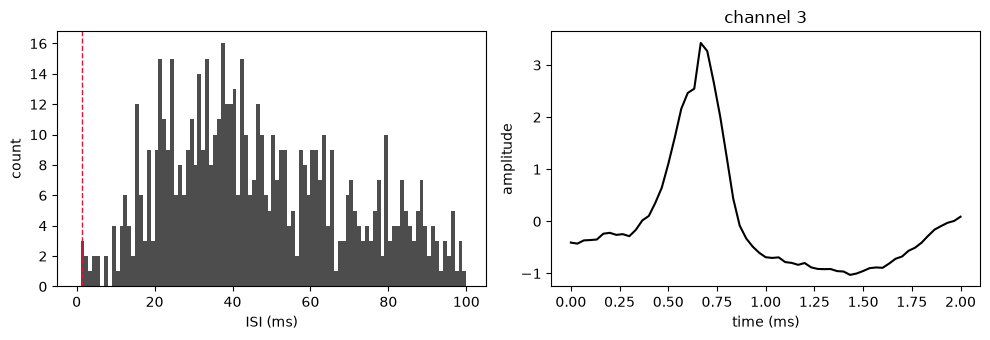

In [39]:
from spikesorting._export import metrics
from spikesorting._export.curated import load_phy_results, select_units
from spikesorting._plots import plot_isi_histogram, plot_mean_waveform

results_dir = config.paths.sorted_for(SYSTEM)
if (results_dir / "spike_times.npy").exists():
    phy = load_phy_results(results_dir)
    unit_id = int(select_units(phy, ("good",))[0])
    times = phy.times_for(unit_id)

    isi = metrics.compute_isi(times)                       # computation
    counts, edges = metrics.compute_isi_histogram(isi)
    violations = metrics.compute_isi_violations(isi)
    print(f"unit {unit_id}: {times.size} spikes, "
          f"{violations['fraction'] * 100:.2f}% refractory violations")

    figure, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)
    plot_isi_histogram(counts, edges, ax=axes[0])          # rendering
    from spikesorting._export.final import mean_template_waveform
    waveform, channel = mean_template_waveform(phy, unit_id)
    plot_mean_waveform(waveform, np.arange(waveform.size) / phy.fs * 1e3, ax=axes[1])
    axes[1].set_title(f"channel {channel}")
    figure.tight_layout()
    plt.show()
else:
    print(f"no sorting in {results_dir} -- run the sorting cell first")